# Exploratory Data Analysis

In [32]:
import librosa
import matplotlib.pyplot as plt
import numpy as np

Data is pulled from gtzan (more info here: https://www.tensorflow.org/datasets/catalog/gtzan). Starting by just loading in a single file to play around with librosa is capable of.

In [33]:
classical, classical_sr = librosa.load("./data/genres_original/classical/classical.00077.wav", sr = 22050, mono = True)

In [34]:
# Data represented simply as a numpy array of amplitude values over time.
print(f'Sample rate: {classical_sr} Hz')
print(f'Duration: {len(classical)/classical_sr:.2f} seconds')
print(f'Number of samples: {len(classical)}')

Sample rate: 22050 Hz
Duration: 30.01 seconds
Number of samples: 661794


In [35]:
tempo, beat_frames = librosa.beat.beat_track(y=classical, sr=classical_sr)

print(f'Estimated tempo: {tempo[0]:.2f} beats per minute')

Estimated tempo: 161.50 beats per minute


In [36]:
# Convert the frame indices of beat events into timestamps
beat_times = librosa.frames_to_time(beat_frames, sr=classical_sr)
beat_times[:5]

array([0.55727891, 0.92879819, 1.32353741, 1.71827664, 2.11301587])

## Waveform Visualization

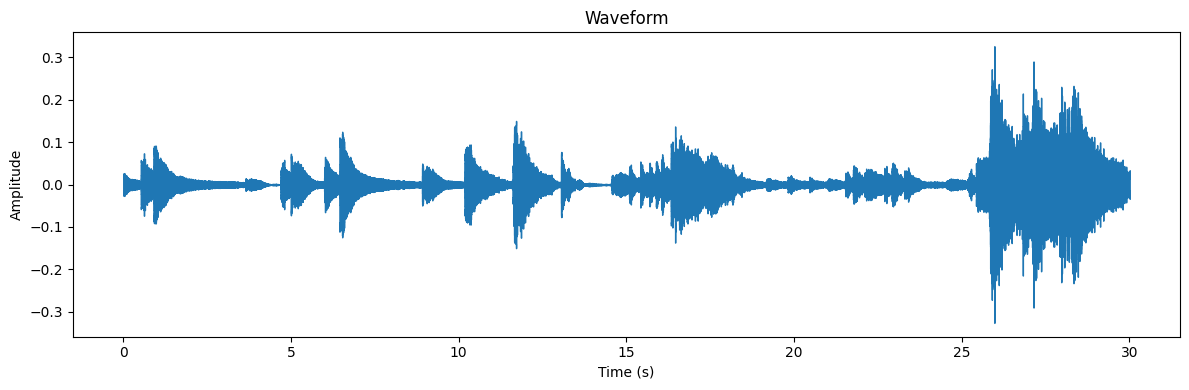

In [37]:
plt.figure(figsize=(12, 4))
librosa.display.waveshow(classical, sr=classical_sr)
plt.title('Waveform')
plt.xlabel('Time (s)')
plt.ylabel('Amplitude')
plt.tight_layout()
plt.show()

Loading in a metal song for comparison

In [ ]:
metal, metal_sr = librosa.load("./data/genres_original/metal/metal.00023.wav", sr = 22050, mono = True)

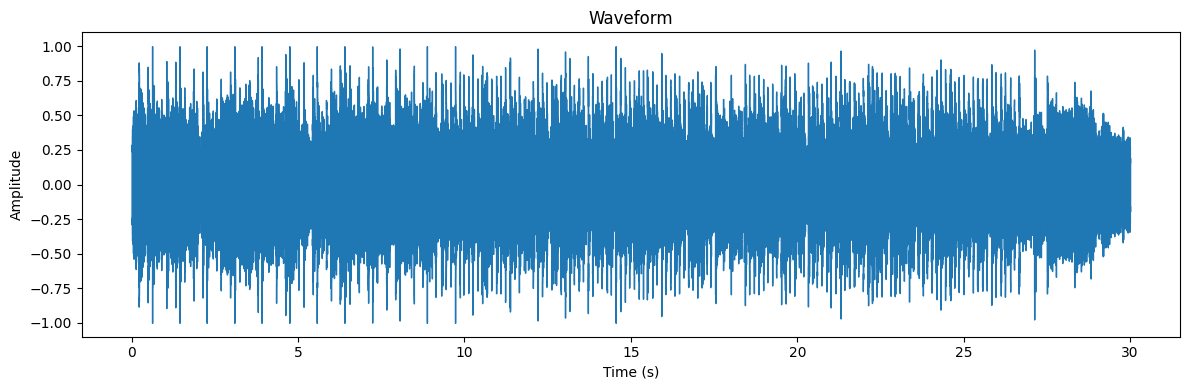

In [39]:
plt.figure(figsize=(12, 4))
librosa.display.waveshow(metal, sr=metal_sr)
plt.title('Waveform')
plt.xlabel('Time (s)')
plt.ylabel('Amplitude')
plt.tight_layout()
plt.show()

## Spectrograms

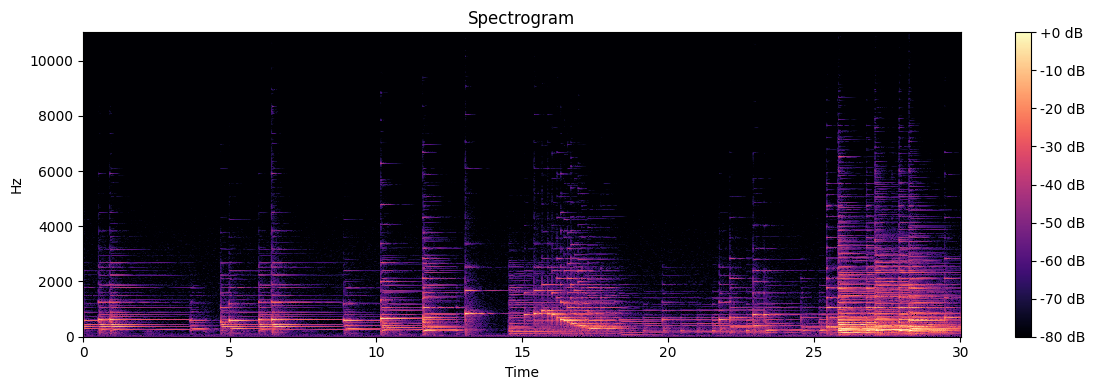

In [40]:
# Uses short-time Fourier transform
D = librosa.stft(classical)
S_db = librosa.amplitude_to_db(np.abs(D), ref=np.max)

plt.figure(figsize=(12, 4))
librosa.display.specshow(S_db, sr=classical_sr, x_axis='time', y_axis='hz')
plt.colorbar(format='%+2.0f dB')
plt.title('Spectrogram')
plt.tight_layout()
plt.show()

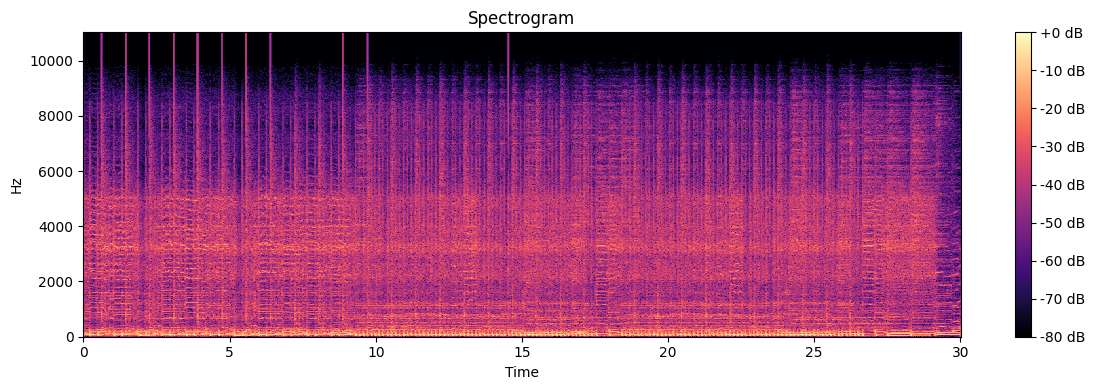

In [41]:
D = librosa.stft(metal)
S_db = librosa.amplitude_to_db(np.abs(D), ref=np.max)

plt.figure(figsize=(12, 4))
librosa.display.specshow(S_db, sr=metal_sr, x_axis='time', y_axis='hz')
plt.colorbar(format='%+2.0f dB')
plt.title('Spectrogram')
plt.tight_layout()
plt.show()

## Mel-frequency cepstral coefficents

A set of coefficients used to measure the "shape" of a frequency at a given time.

MFCC shape: (13, 1293)
MFCC means: [-477.94  155.32   12.76    5.53    2.38  -10.65  -16.65  -12.55  -11.19
   -9.37   -3.22   -2.77   -6.48]


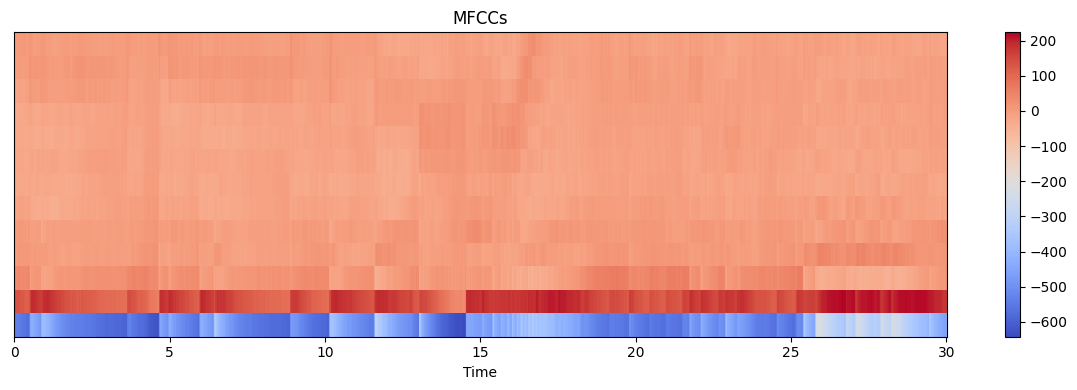

In [42]:
mfccs = librosa.feature.mfcc(y=classical, sr=classical_sr, n_mfcc=13)

print(f'MFCC shape: {mfccs.shape}')  # (13, time_frames)
print(f'MFCC means: {mfccs.mean(axis=1).round(2)}')

plt.figure(figsize=(12, 4))
librosa.display.specshow(mfccs, sr=classical_sr, x_axis='time')
plt.colorbar()
plt.title('MFCCs')
plt.tight_layout()
plt.show()

MFCC shape: (13, 1293)
MFCC means: [-43.8   82.77 -29.61  70.4  -21.59  31.14   2.09  28.87  -2.69  19.88
  -6.93  19.12  -7.37]


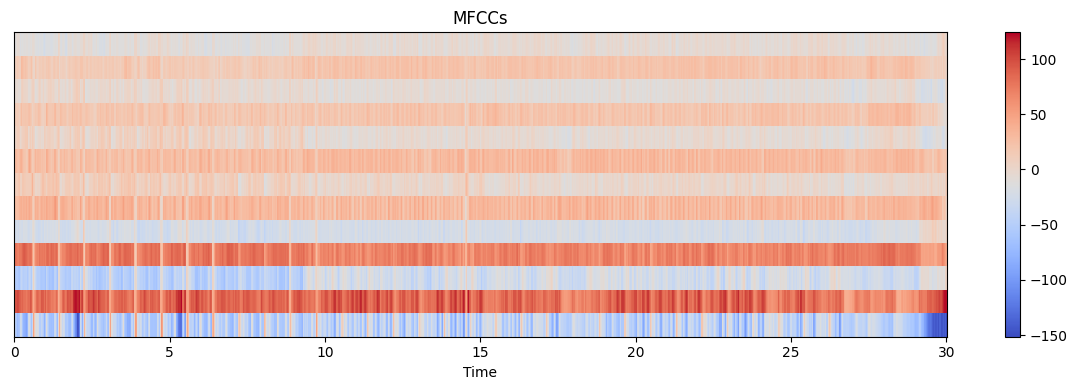

In [44]:
mfccs = librosa.feature.mfcc(y=metal, sr=metal_sr, n_mfcc=13)

print(f'MFCC shape: {mfccs.shape}')  # (13, time_frames)
print(f'MFCC means: {mfccs.mean(axis=1).round(2)}')

plt.figure(figsize=(12, 4))
librosa.display.specshow(mfccs, sr=metal_sr, x_axis='time')
plt.colorbar()
plt.title('MFCCs')
plt.tight_layout()
plt.show()

Rough interpretation: the classical image shows smooth, consistent texture over time with a wide range in the scale representing large dynamic swings. The metal one shows more rapid oscillations but a narrower overall range, showing more heavily produced, distorted sound. 

## Spectral Features

Mean spectral centroid: 812.12 Hz
Mean spectral rolloff: 1236.46 Hz
Mean zero crossing rate: 0.0483


/var/folders/0j/45q1_hkx01sd7_mfg_4ph6mh0000gn/T/ipykernel_14878/1924359916.py:20: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.tight_layout()


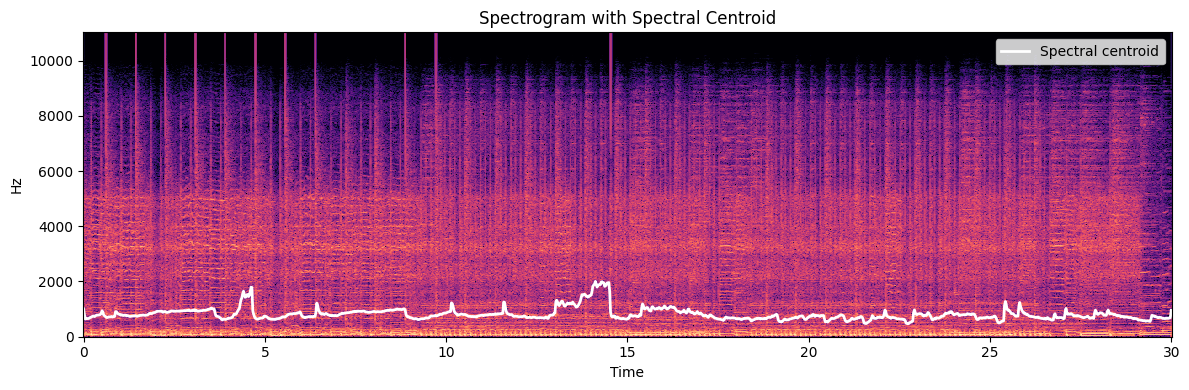

In [46]:
# Spectral centroid — "brightness" of the sound
centroid = librosa.feature.spectral_centroid(y=classical, sr=classical_sr)
print(f'Mean spectral centroid: {centroid.mean():.2f} Hz')

# Spectral rolloff
rolloff = librosa.feature.spectral_rolloff(y=classical, sr=classical_sr)
print(f'Mean spectral rolloff: {rolloff.mean():.2f} Hz')

# Zero crossing rate
zcr = librosa.feature.zero_crossing_rate(classical)
print(f'Mean zero crossing rate: {zcr.mean():.4f}')

# Visualize centroid over time on top of spectrogram
plt.figure(figsize=(12, 4))
librosa.display.specshow(S_db, sr=classical_sr, x_axis='time', y_axis='hz')
times = librosa.times_like(centroid, sr=classical_sr)
plt.plot(times, centroid[0], color='white', linewidth=2, label='Spectral centroid')
plt.legend()
plt.title('Spectrogram with Spectral Centroid')
plt.tight_layout()
plt.show()

Mean spectral centroid: 2575.35 Hz
Mean spectral rolloff: 5056.74 Hz
Mean zero crossing rate: 0.1317


/var/folders/0j/45q1_hkx01sd7_mfg_4ph6mh0000gn/T/ipykernel_14878/1571790572.py:20: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.tight_layout()


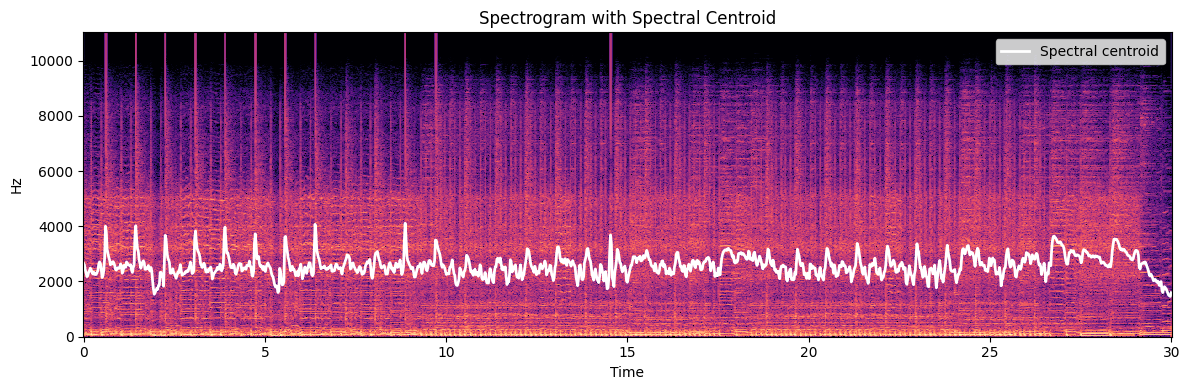

In [47]:
# Spectral centroid — "brightness" of the sound
centroid = librosa.feature.spectral_centroid(y=metal, sr=metal_sr)
print(f'Mean spectral centroid: {centroid.mean():.2f} Hz')

# Spectral rolloff
rolloff = librosa.feature.spectral_rolloff(y=metal, sr=metal_sr)
print(f'Mean spectral rolloff: {rolloff.mean():.2f} Hz')

# Zero crossing rate
zcr = librosa.feature.zero_crossing_rate(metal)
print(f'Mean zero crossing rate: {zcr.mean():.4f}')

# Visualize centroid over time on top of spectrogram
plt.figure(figsize=(12, 4))
librosa.display.specshow(S_db, sr=metal_sr, x_axis='time', y_axis='hz')
times = librosa.times_like(centroid, sr=metal_sr)
plt.plot(times, centroid[0], color='white', linewidth=2, label='Spectral centroid')
plt.legend()
plt.title('Spectrogram with Spectral Centroid')
plt.tight_layout()
plt.show()

Classical has a much lower average frequency and is much more stable overall. Metal is higher and more jagged, representing things like distorted guitars.

# Rhythm Features

Estimated tempo: 161.50 beats per minute
Mean chroma: [0.175 0.094 0.283 0.402 0.191 0.33  0.199 0.192 0.275 0.164 0.159 0.164]


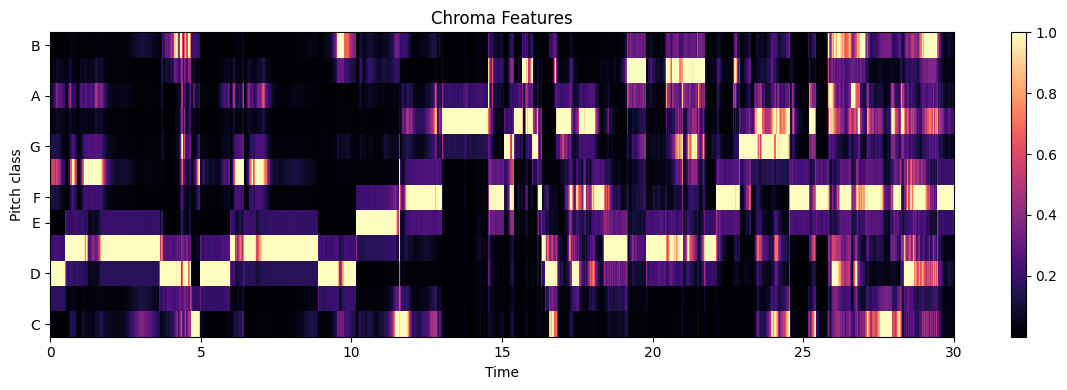

In [48]:
# Tempo
tempo, beats = librosa.beat.beat_track(y=classical, sr=classical_sr)
print(f'Estimated tempo: {tempo[0]:.2f} beats per minute')

# Chroma — harmonic content
chroma = librosa.feature.chroma_stft(y=classical, sr=classical_sr)
print(f'Mean chroma: {chroma.mean(axis=1).round(3)}')

plt.figure(figsize=(12, 4))
librosa.display.specshow(chroma, sr=classical_sr, x_axis='time', y_axis='chroma')
plt.colorbar()
plt.title('Chroma Features')
plt.tight_layout()
plt.show()

Estimated tempo: 143.55 beats per minute
Mean chroma: [0.653 0.559 0.555 0.55  0.548 0.514 0.445 0.545 0.541 0.41  0.463 0.546]


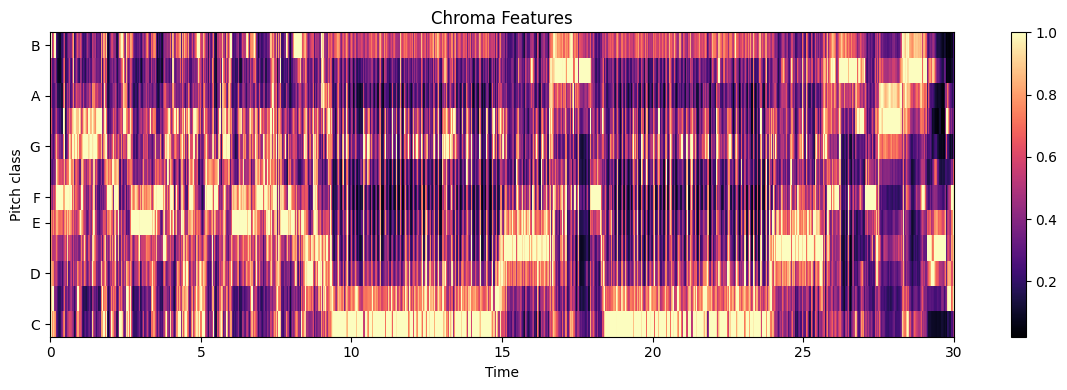

In [49]:
# Tempo
tempo, beats = librosa.beat.beat_track(y=metal, sr=metal_sr)
print(f'Estimated tempo: {tempo[0]:.2f} beats per minute')

# Chroma — harmonic content
chroma = librosa.feature.chroma_stft(y=metal, sr=metal_sr)
print(f'Mean chroma: {chroma.mean(axis=1).round(3)}')

plt.figure(figsize=(12, 4))
librosa.display.specshow(chroma, sr=metal_sr, x_axis='time', y_axis='chroma')
plt.colorbar()
plt.title('Chroma Features')
plt.tight_layout()
plt.show()

# RMS Energy

Mean RMS energy: 0.0167
RMS std (dynamic range proxy): 0.0177


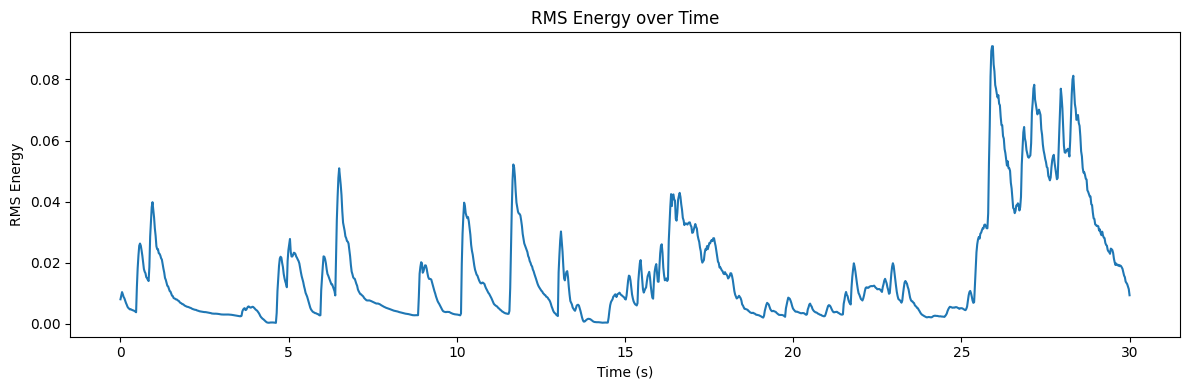

In [50]:
rms = librosa.feature.rms(y=classical)
print(f'Mean RMS energy: {rms.mean():.4f}')
print(f'RMS std (dynamic range proxy): {rms.std():.4f}')

plt.figure(figsize=(12, 4))
times = librosa.times_like(rms, sr=classical_sr)
plt.plot(times, rms[0])
plt.title('RMS Energy over Time')
plt.xlabel('Time (s)')
plt.ylabel('RMS Energy')
plt.tight_layout()
plt.show()

Mean RMS energy: 0.1952
RMS std (dynamic range proxy): 0.0357


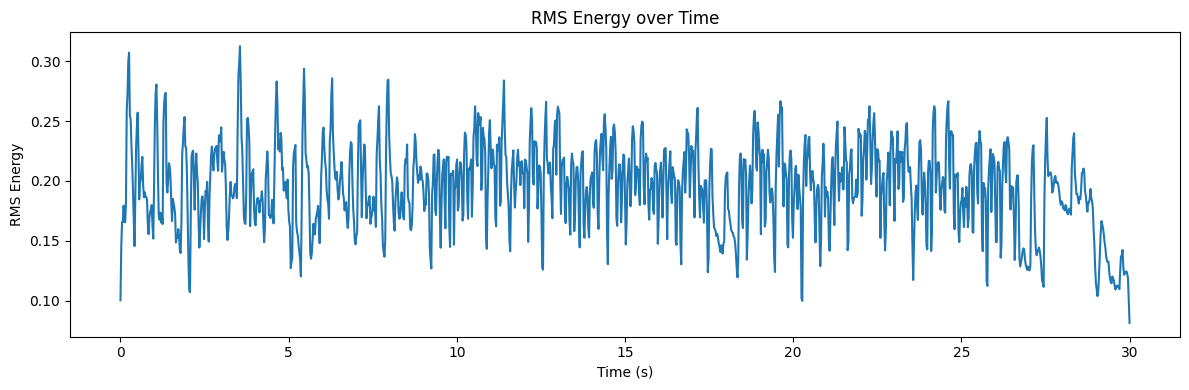

In [51]:
rms = librosa.feature.rms(y=metal)
print(f'Mean RMS energy: {rms.mean():.4f}')
print(f'RMS std (dynamic range proxy): {rms.std():.4f}')

plt.figure(figsize=(12, 4))
times = librosa.times_like(rms, sr=metal_sr)
plt.plot(times, rms[0])
plt.title('RMS Energy over Time')
plt.xlabel('Time (s)')
plt.ylabel('RMS Energy')
plt.tight_layout()
plt.show()

Think this one's pretty clear lol. Mostly fits the same kind of patterns that we've already established, no surprise that metal is higher energy and fluctuates more.

Alright, done walking through the features and I feel like I have a pretty good grasp of what librosa is capable of. Seems like several of these can definitely be used for classification. On to a proper feature extraction pipeline!